# PROJECT 2

## MGMTMFE 432

## SPRING 2025

You will need to write codes for all the parts of the project. Make sure the codes work properly and understand the ideas behind each problem below. You may be asked to demonstrate how the codes work, by running them and interpreting the results. Code quality, speed, and accuracy will determine the grades.

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy import optimize
from scipy.interpolate import interp1d
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
import time
from scipy.sparse import diags

sns.set(style="whitegrid")
sns.set_context("notebook", font_scale=1.2)
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["figure.dpi"] = 100

## LECTURE-4 [Binomial-tree, Trinomial-tree models]

1. Compare the convergence rates of the four methods below by doing the following:

Use the Binomial Method to price a 6-month American Put option with the following information: the risk-free interest rate is 5.5% per annum; the volatility is 25% per annum; the current stock price is $180; and the strike price is 𝐾 = $180. Divide the time interval into 𝑛 parts to estimate the price of this option. Use 𝑛 = 20, 40, 80, 100, 200, 500, to estimate the price and draw all resulting prices in one graph, where the horizontal axis measures 𝑛, and the vertical one the price of the option.

**(a)** Use the binomial method in which

$$
u = \frac{1}{d}, \quad d = c - \sqrt{c^2 - 1}, \quad c = \frac{1}{2}(e^{-r\Delta} + e^{(r+\sigma^2)\Delta}), \quad p = \frac{e^{r\Delta} - d}{u - d}
$$

**(b)** Use the binomial method in which

$$
u = e^{(r - \frac{\sigma^2}{2})\Delta + \sigma\sqrt{\Delta}}, \quad d = e^{(r - \frac{\sigma^2}{2})\Delta - \sigma\sqrt{\Delta}}, \quad p = \frac{1}{2}
$$

Outputs: Graphs: Two plots in one graph.

---

## Problem 1: Binomial Tree Methods Comparison

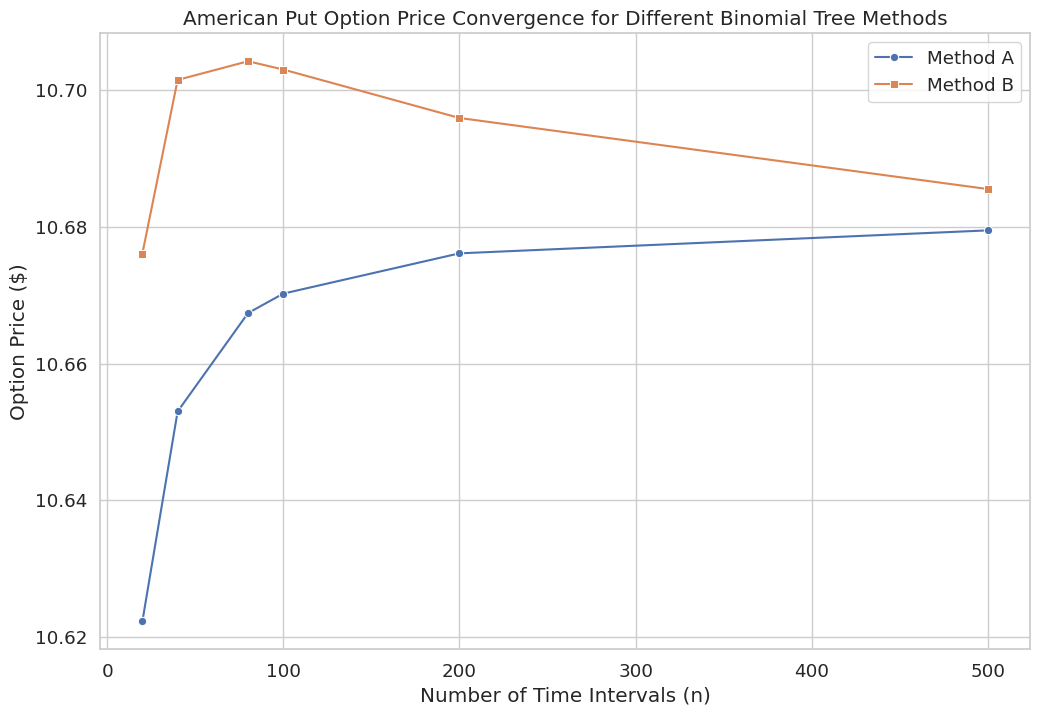

In [3]:
def binomial_tree_a(S0, K, r, sigma, T, n):
    dt = T / n
    c = 0.5 * (np.exp(-r * dt) + np.exp((r + sigma**2) * dt))
    d = c - np.sqrt(c**2 - 1)
    u = 1 / d
    p = (np.exp(r * dt) - d) / (u - d)
    
    stock = np.zeros((n+1, n+1))
    for i in range(n+1):
        for j in range(i+1):
            stock[j, i] = S0 * (u**(i-j)) * (d**j)
    
    option = np.zeros((n+1, n+1))
    
    for i in range(n+1):
        option[i, n] = max(K - stock[i, n], 0)
    
    for i in range(n-1, -1, -1):
        for j in range(i+1):
            expected = p * option[j, i+1] + (1-p) * option[j+1, i+1]
            expected *= np.exp(-r * dt)
            option[j, i] = max(expected, K - stock[j, i])
    
    return option[0, 0]

def binomial_tree_b(S0, K, r, sigma, T, n):
    dt = T / n
    u = np.exp((r - sigma**2/2) * dt + sigma * np.sqrt(dt))
    d = np.exp((r - sigma**2/2) * dt - sigma * np.sqrt(dt))
    p = 0.5
    
    stock = np.zeros((n+1, n+1))
    for i in range(n+1):
        for j in range(i+1):
            stock[j, i] = S0 * (u**(i-j)) * (d**j)
    
    option = np.zeros((n+1, n+1))
    
    for i in range(n+1):
        option[i, n] = max(K - stock[i, n], 0)
    
    for i in range(n-1, -1, -1):
        for j in range(i+1):
            expected = p * option[j, i+1] + (1-p) * option[j+1, i+1]
            expected *= np.exp(-r * dt)
            option[j, i] = max(expected, K - stock[j, i])
    
    return option[0, 0]

S0 = 180
K = 180
r = 0.055
sigma = 0.25
T = 0.5

n_values = [20, 40, 80, 100, 200, 500]

prices_a = [binomial_tree_a(S0, K, r, sigma, T, n) for n in n_values]
prices_b = [binomial_tree_b(S0, K, r, sigma, T, n) for n in n_values]

plt.figure(figsize=(12, 8))
sns.lineplot(x=n_values, y=prices_a, marker='o', label='Method A')
sns.lineplot(x=n_values, y=prices_b, marker='s', label='Method B')
plt.title('American Put Option Price Convergence for Different Binomial Tree Methods')
plt.xlabel('Number of Time Intervals (n)')
plt.ylabel('Option Price ($)')
plt.grid(True)
plt.legend()
plt.show()

2. Consider the following information on the stock of a company and American put options on it:

$$
S_0 = 180,\; K = 180,\; r = 0.055,\; \sigma = 0.25,\; T = 6 \; months,\; \mu = 0.15
$$

Using the CRR Binomial tree method, estimate the following and draw their graphs:

**(i)** Delta of the put option as a function of 𝑆₀, for 𝑆₀ ranging from $170 to $190, in increments of $2.

**(ii)** Delta of the put option, as a function of T (time to expiration), T ranging from 0 to 0.18 in increments of 0.003.

**(iii)** Theta of the put option, as a function of T (time to expiration), T ranging from 0 to 0.18 in increments of 0.003.

**(iv)** Vega of the put option, as a function of 𝑆₀, for 𝑆₀ ranging from $170 to $190, in increments of $2.

Note: In the CRR model,

$$
u = e^{\sigma \sqrt{\Delta}}, \quad d = e^{-\sigma \sqrt{\Delta}}, \quad p = \frac{e^{r\Delta} - d}{u - d}
$$

Outputs: Graphs: 4 separate graphs.

---


## Problem 2: CRR Binomial Tree for Option Greeks

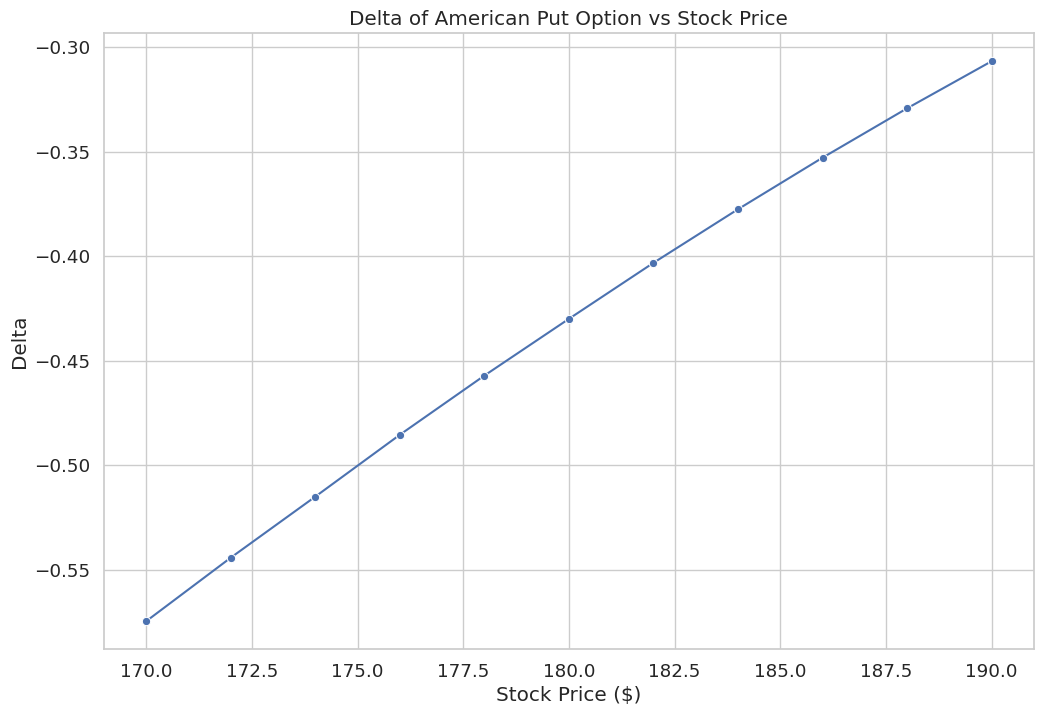

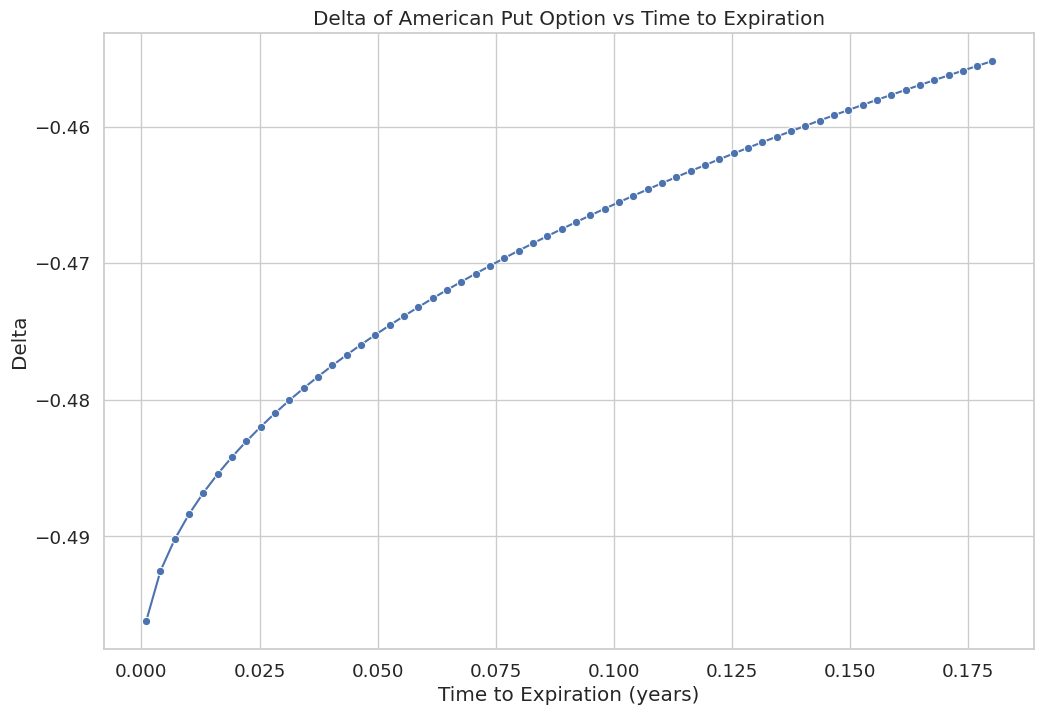

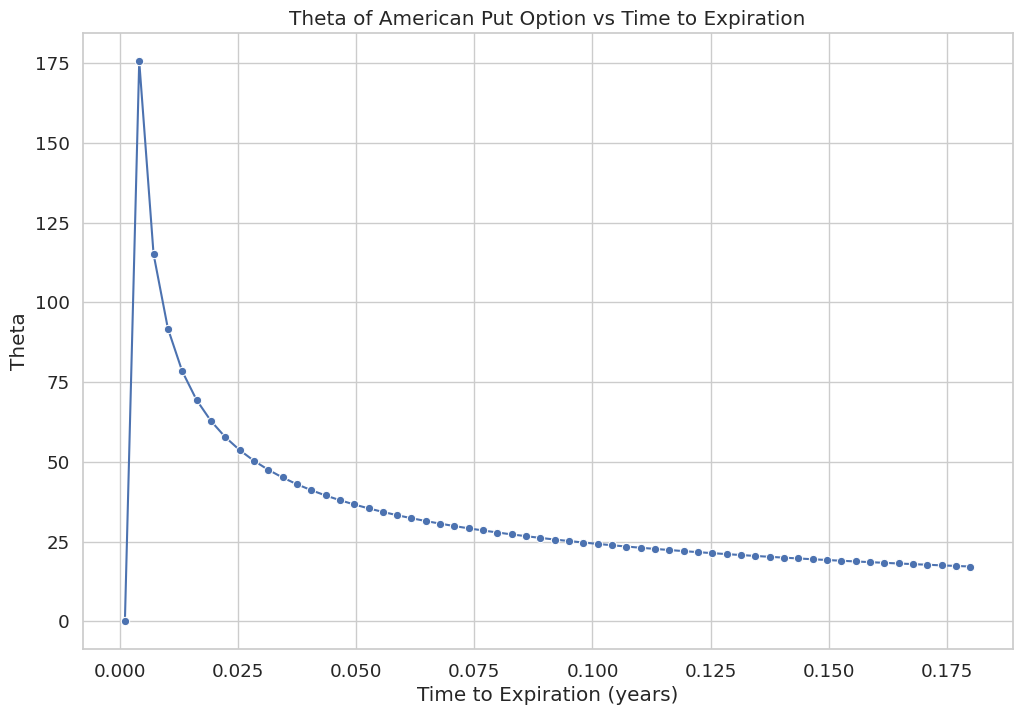

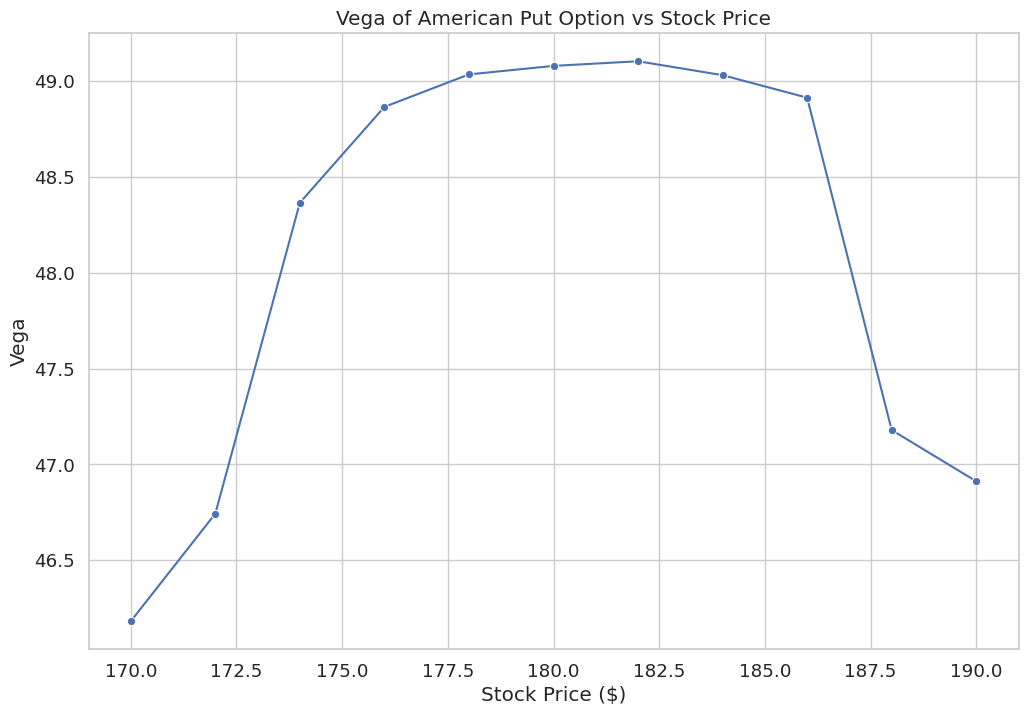

In [4]:
def crr_binomial_american_put(S0, K, r, sigma, T, n):
    dt = T / n
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    
    stock = np.zeros((n+1, n+1))
    for i in range(n+1):
        for j in range(i+1):
            stock[j, i] = S0 * (u**(i-j)) * (d**j)
    
    option = np.zeros((n+1, n+1))
    
    for i in range(n+1):
        option[i, n] = max(K - stock[i, n], 0)
    
    for i in range(n-1, -1, -1):
        for j in range(i+1):
            expected = p * option[j, i+1] + (1-p) * option[j+1, i+1]
            expected *= np.exp(-r * dt)
            option[j, i] = max(expected, K - stock[j, i])
    
    if n > 1:
        delta = (option[0, 1] - option[1, 1]) / (stock[0, 1] - stock[1, 1])
    else:
        delta = (option[0, 0] - K + S0) / S0 if S0 < K else -1
    
    return option[0, 0], delta

def calculate_delta_vs_stock(K, r, sigma, T, n, stock_range):
    deltas = []
    prices = []
    for S0 in stock_range:
        price, delta = crr_binomial_american_put(S0, K, r, sigma, T, n)
        prices.append(price)
        deltas.append(delta)
    return prices, deltas

def calculate_greeks_vs_time(S0, K, r, sigma, time_range, n):
    deltas = []
    thetas = []
    base_price = None
    
    for T in time_range:
        price, delta = crr_binomial_american_put(S0, K, r, sigma, T, n)
        deltas.append(delta)
        
        if T + 1/365 in time_range:
            next_idx = np.where(np.isclose(time_range, T + 1/365))[0][0]
            next_price = crr_binomial_american_put(S0, K, r, sigma, time_range[next_idx], n)[0]
            theta = (next_price - price) / (1/365)
        else:
            if T > 1/365:
                prev_T = max(0, T - 1/365)
                prev_price = crr_binomial_american_put(S0, K, r, sigma, prev_T, n)[0]
                theta = (price - prev_price) / (1/365)
            else:
                theta = 0
        
        thetas.append(theta)
    
    return deltas, thetas

def calculate_vega_vs_stock(K, r, sigma, T, n, stock_range, d_sigma=0.01):
    vegas = []
    for S0 in stock_range:
        price1 = crr_binomial_american_put(S0, K, r, sigma, T, n)[0]
        price2 = crr_binomial_american_put(S0, K, r, sigma + d_sigma, T, n)[0]
        vega = (price2 - price1) / d_sigma
        vegas.append(vega)
    return vegas

S0 = 180
K = 180
r = 0.055
sigma = 0.25
T = 0.5
mu = 0.15
n = 100

stock_range = np.arange(170, 191, 2)
prices, deltas = calculate_delta_vs_stock(K, r, sigma, T, n, stock_range)

plt.figure(figsize=(12, 8))
sns.lineplot(x=stock_range, y=deltas, marker='o')
plt.title('Delta of American Put Option vs Stock Price')
plt.xlabel('Stock Price ($)')
plt.ylabel('Delta')
plt.grid(True)
plt.show()

time_range = np.linspace(0.001, 0.18, 60)
deltas_t, thetas_t = calculate_greeks_vs_time(S0, K, r, sigma, time_range, n)

plt.figure(figsize=(12, 8))
sns.lineplot(x=time_range, y=deltas_t, marker='o')
plt.title('Delta of American Put Option vs Time to Expiration')
plt.xlabel('Time to Expiration (years)')
plt.ylabel('Delta')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 8))
sns.lineplot(x=time_range, y=thetas_t, marker='o')
plt.title('Theta of American Put Option vs Time to Expiration')
plt.xlabel('Time to Expiration (years)')
plt.ylabel('Theta')
plt.grid(True)
plt.show()

vegas = calculate_vega_vs_stock(K, r, sigma, T, n, stock_range)

plt.figure(figsize=(12, 8))
sns.lineplot(x=stock_range, y=vegas, marker='o')
plt.title('Vega of American Put Option vs Stock Price')
plt.xlabel('Stock Price ($)')
plt.ylabel('Vega')
plt.grid(True)
plt.show()

3. Compare the convergence rates of the two methods, (a) and (b), described below, by doing the following:

Use the Trinomial-tree method to price a 6-month American put option with the following information: the risk-free interest rate is 5.5% per annum, the volatility is 25% per annum, the current stock price is $180, and the strike price is 𝐾 = $180.

Divide the time interval into 𝑛 equal parts to estimate the option price. Use n = 20, 40, 70, 80, 100, 200, 500; to estimate option prices and draw them all in one graph, where the horizontal axis measures 𝑛, and the vertical one measures option price.

The two methods are in (a) and (b) below:

**(a)** Use the Trinomial-tree method applied to the stock price-process (𝑆ₜ) in which

$$
u = \frac{1}{d}, \quad d = e^{-\sigma \sqrt{3\Delta}}, \quad p_d = \frac{r\Delta (1 - u) + (r\Delta)^2 + \sigma^2 \Delta}{(u - d)(1 - d)}, \quad p_u = \frac{r\Delta (1 - d) + (r\Delta)^2 + \sigma^2 \Delta}{(u - d)(u - 1)}, \quad p_m = 1 - p_u - p_d
$$

**(b)** Use the Trinomial-tree method applied to the Log-stock price-process (𝑋ₜ) in which

$$
\Delta X_u = \sigma \sqrt{3\Delta}, \quad \Delta X_d = -\sigma \sqrt{3\Delta}
$$

$$
p_d = \frac{1}{2}\left(\frac{\sigma^2 \Delta + (r - \frac{\sigma^2}{2})^2 \Delta^2}{\Delta X_u^2} - \frac{(r - \frac{\sigma^2}{2})\Delta}{\Delta X_u}\right), \quad p_u = \frac{1}{2}\left(\frac{\sigma^2 \Delta + (r - \frac{\sigma^2}{2})^2 \Delta^2}{\Delta X_u^2} + \frac{(r - \frac{\sigma^2}{2})\Delta}{\Delta X_u}\right), \quad p_m = 1 - p_u - p_d
$$

Outputs: Graphs: plot in a graph.

---


## Problem 3: Trinomial Tree Methods Comparison

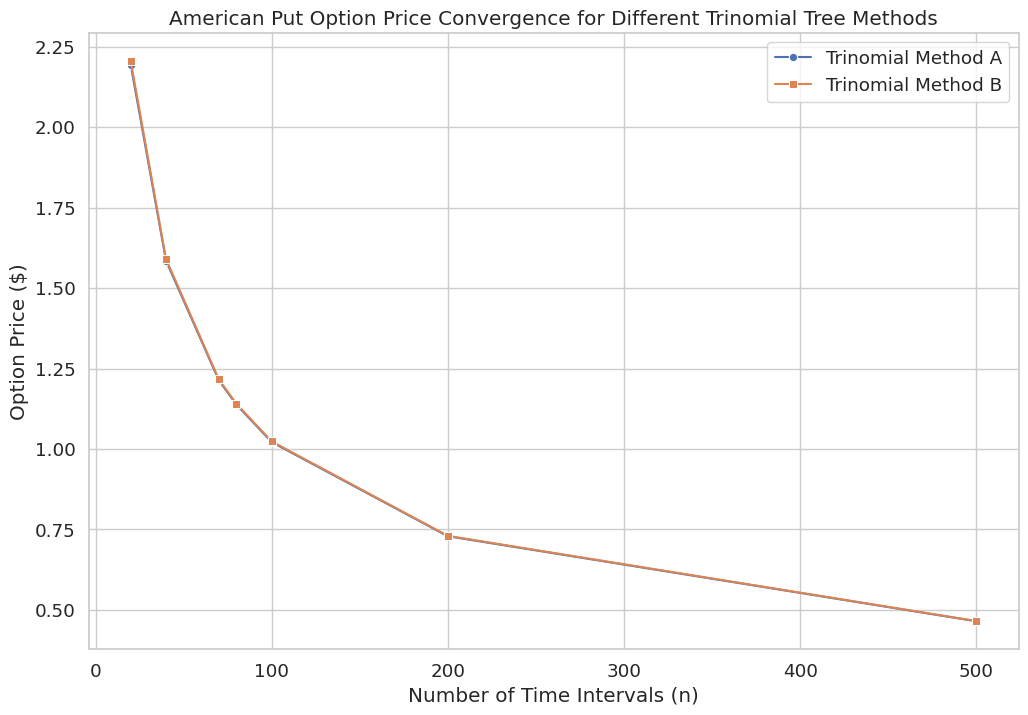

In [5]:
def trinomial_tree_a(S0, K, r, sigma, T, n):
    dt = T / n
    d = np.exp(-sigma * np.sqrt(3 * dt))
    u = 1 / d
    
    p_d = (r * dt * (1 - u) + (r * dt)**2 + sigma**2 * dt) / ((u - d) * (1 - d))
    p_u = (r * dt * (1 - d) + (r * dt)**2 + sigma**2 * dt) / ((u - d) * (u - 1))
    p_m = 1 - p_u - p_d
    
    stock = np.zeros((2*n+1, n+1))
    stock[n, 0] = S0
    
    for j in range(1, n+1):
        for i in range(2*n+1):
            up_power = max(0, j - i + n)
            down_power = max(0, i - n)
            
            if up_power + down_power <= j:
                stock[i, j] = S0 * (u ** up_power) * (d ** down_power)
    
    option = np.zeros((2*n+1, n+1))
    
    for i in range(2*n+1):
        if stock[i, n] > 0:
            option[i, n] = max(K - stock[i, n], 0)
    
    for j in range(n-1, -1, -1):
        for i in range(2*n+1):
            if stock[i, j] > 0:
                up_idx = max(0, min(2*n, i-1))
                mid_idx = i
                down_idx = min(2*n, i+1)
                
                expected = p_u * option[up_idx, j+1] + p_m * option[mid_idx, j+1] + p_d * option[down_idx, j+1]
                expected *= np.exp(-r * dt)
                
                option[i, j] = max(expected, K - stock[i, j])
    
    return option[n, 0]

def trinomial_tree_b(S0, K, r, sigma, T, n):
    dt = T / n
    dX_u = sigma * np.sqrt(3 * dt)
    dX_d = -dX_u
    
    drift = r - sigma**2/2
    p_d = 0.5 * ((sigma**2 * dt + drift**2 * dt**2) / dX_u**2 - drift * dt / dX_u)
    p_u = 0.5 * ((sigma**2 * dt + drift**2 * dt**2) / dX_u**2 + drift * dt / dX_u)
    p_m = 1 - p_u - p_d
    
    logS = np.zeros((2*n+1, n+1))
    logS[n, 0] = np.log(S0)
    
    for j in range(1, n+1):
        for i in range(2*n+1):
            net_moves = j - i + n
            
            if 0 <= net_moves <= 2*j:
                logS[i, j] = np.log(S0) + (j - i + n) * dX_u + (i - n) * dX_d
    
    stock = np.exp(logS)
    
    option = np.zeros((2*n+1, n+1))
    
    for i in range(2*n+1):
        if stock[i, n] > 0:
            option[i, n] = max(K - stock[i, n], 0)
    
    for j in range(n-1, -1, -1):
        for i in range(2*n+1):
            if stock[i, j] > 0:
                up_idx = max(0, min(2*n, i-1))
                mid_idx = i
                down_idx = min(2*n, i+1)
                
                expected = p_u * option[up_idx, j+1] + p_m * option[mid_idx, j+1] + p_d * option[down_idx, j+1]
                expected *= np.exp(-r * dt)
                
                option[i, j] = max(expected, K - stock[i, j])
    
    return option[n, 0]

S0 = 180
K = 180
r = 0.055
sigma = 0.25
T = 0.5

n_values = [20, 40, 70, 80, 100, 200, 500]

prices_a = [trinomial_tree_a(S0, K, r, sigma, T, n) for n in n_values]
prices_b = [trinomial_tree_b(S0, K, r, sigma, T, n) for n in n_values]

plt.figure(figsize=(12, 8))
sns.lineplot(x=n_values, y=prices_a, marker='o', label='Trinomial Method A')
sns.lineplot(x=n_values, y=prices_b, marker='s', label='Trinomial Method B')
plt.title('American Put Option Price Convergence for Different Trinomial Tree Methods')
plt.xlabel('Number of Time Intervals (n)')
plt.ylabel('Option Price ($)')
plt.grid(True)
plt.legend()
plt.show()

## LECTURE - 5 [Least Square Monte Carlo method]

4. Consider the following information on the stock of company XYZ: The current stock price is $180, and the volatility of the stock price is $\sigma = 25\%$ per annum. Assume the prevailing risk-free rate is $r = 5.5\%$ per annum. Use the following method to price the specified option:

**(a)** Use the LSMC method with $N=100,000$ paths simulations ($50,000$ plus $50,000$ antithetic variates) and a time step of $\Delta = \frac{1}{\sqrt{N}}$ to price an American Put option with strike price of $K = 180$ and maturity of 0.5-years and 1.5-years. Use the first $k$ of the Laguerre Polynomials for $k = 2, 3, 4, 5$. (That is, you will compute 8 prices here). Compare the prices for the 4 cases, $k = 2, 3, 4, 5$ and comment on the choice of k.

**(b)** Use the LSMC method with $N=100,000$ paths simulations ($50,000$ plus $50,000$ antithetic variates) and a time step of $\Delta = \frac{1}{\sqrt{N}}$ to price an American Put option with strike price of $K = 180$ and maturity of 0.5-years and 1.5-years. Use the first $k$ of the Hermite Polynomials for $k = 2, 3, 4, 5$. (That is, you will compute 8 prices here). Compare the prices for the 4 cases, $k = 2, 3, 4, 5$ and comment on the choice of k.

**(c)** Use the LSMC method with $N=100,000$ paths simulations ($50,000$ plus $50,000$ antithetic variates) and a time step of $\Delta = \frac{1}{\sqrt{N}}$ to price an American Put option with strike price of $K = 180$ and maturity of 0.5-years and 1.5-years. Use the first $k$ of the Simple Monomials for $k = 2, 3, 4, 5$. (That is, you will compute 8 prices here). Compare the prices for the 4 cases, $k = 2, 3, 4, 5$ and comment on the choice of k.

**(d)** Compare all your findings above and comment.

Note: You will need to use the weighted-polynomials as it was done by the authors of the method.

Inputs: $S_0, K, T, r, \sigma, N, k$

Outputs: Values of Option Prices; writeup: comments.

---

## Problem 4: Least Square Monte Carlo (LSMC) Method


Laguerre Polynomials:
  T = 0.5 years:
    k = 2: 10.4648
    k = 3: 10.5871
    k = 4: 10.6392
    k = 5: 10.6446
  T = 1.5 years:
    k = 2: 15.8890
    k = 3: 16.1647
    k = 4: 16.2197
    k = 5: 16.2339

Hermite Polynomials:
  T = 0.5 years:
    k = 2: 10.4648
    k = 3: 10.5871
    k = 4: 10.6392
    k = 5: 10.6446
  T = 1.5 years:
    k = 2: 15.8890
    k = 3: 16.1647
    k = 4: 16.2197
    k = 5: 16.2339

Monomial Polynomials:
  T = 0.5 years:
    k = 2: 10.4648
    k = 3: 10.5871
    k = 4: 10.6392
    k = 5: 10.6446
  T = 1.5 years:
    k = 2: 15.8890
    k = 3: 16.1647
    k = 4: 16.2197
    k = 5: 16.2339


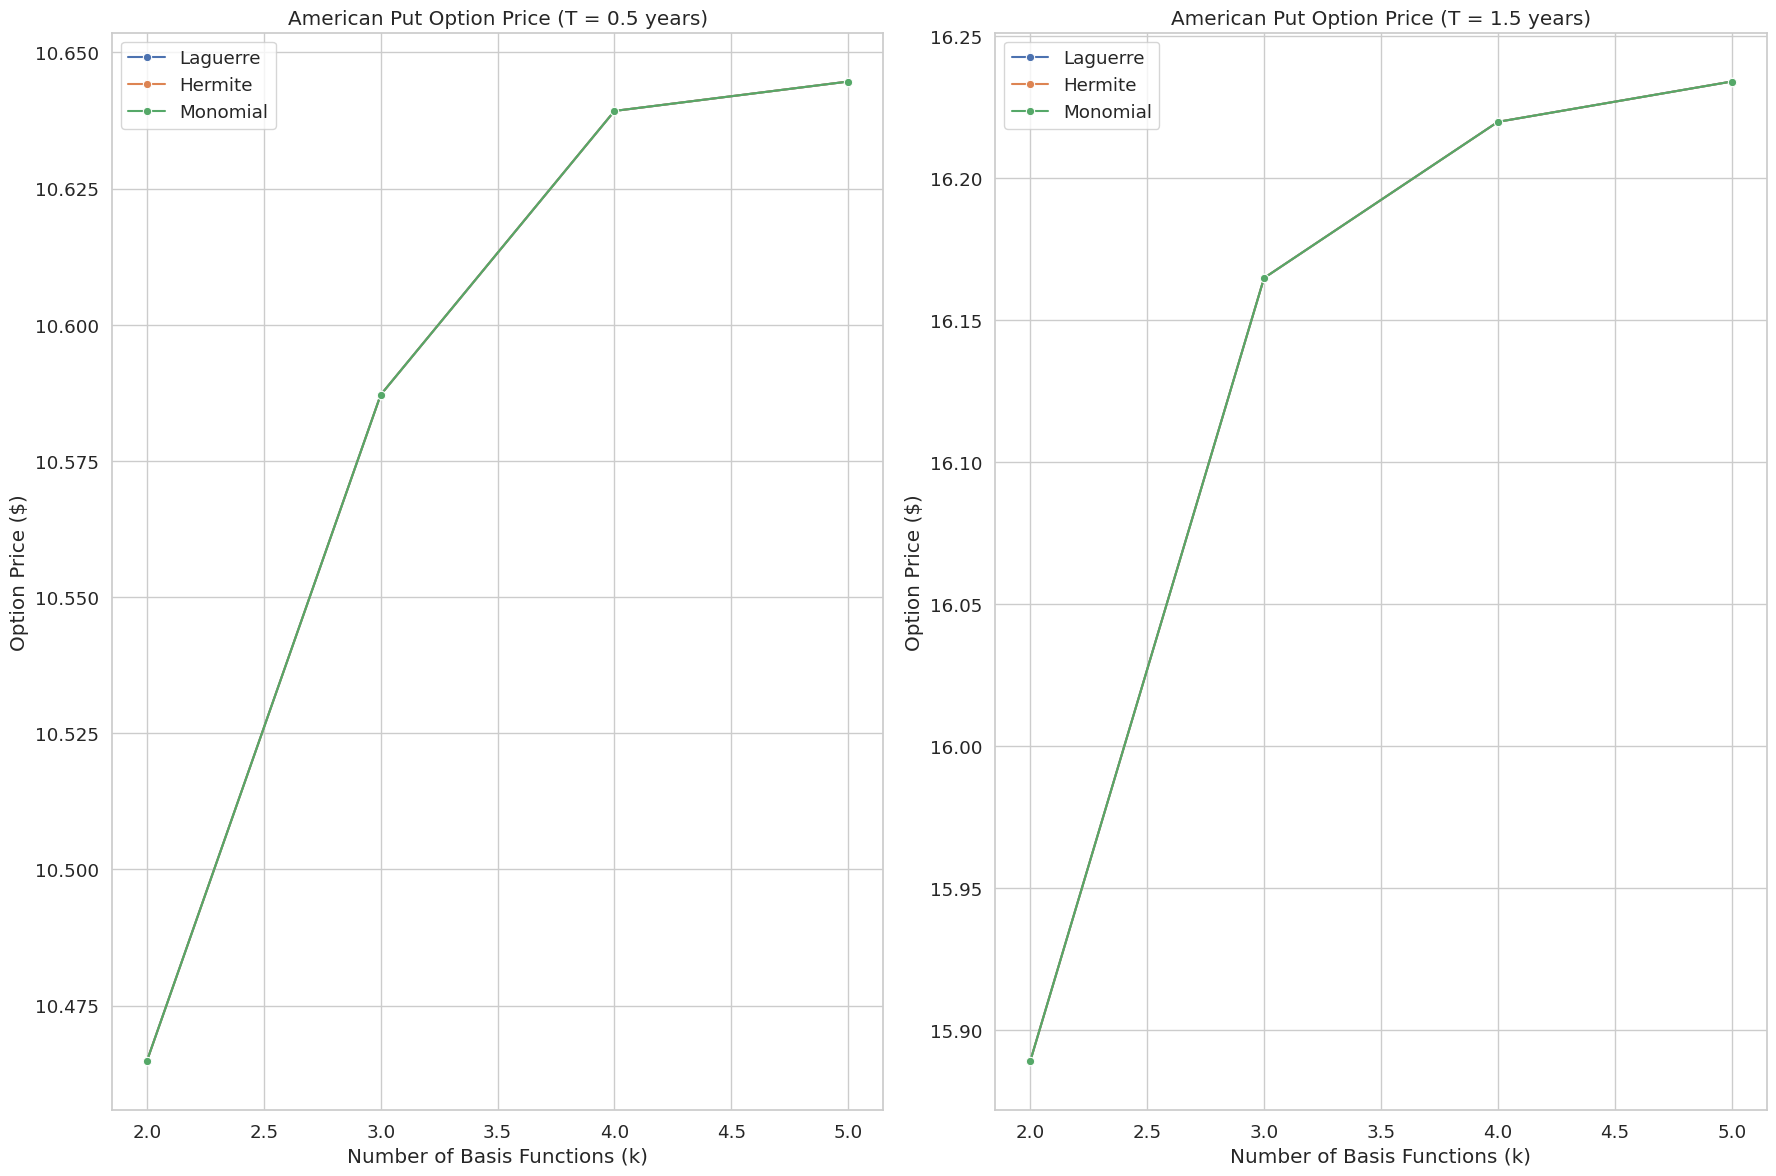

In [6]:
def laguerre(x, k):
    if k == 0:
        return np.ones_like(x)
    elif k == 1:
        return 1 - x
    elif k == 2:
        return 0.5 * (x**2 - 4*x + 2)
    elif k == 3:
        return (1/6) * (-x**3 + 9*x**2 - 18*x + 6)
    elif k == 4:
        return (1/24) * (x**4 - 16*x**3 + 72*x**2 - 96*x + 24)
    elif k == 5:
        return (1/120) * (-x**5 + 25*x**4 - 200*x**3 + 600*x**2 - 600*x + 120)

def hermite(x, k):
    if k == 0:
        return np.ones_like(x)
    elif k == 1:
        return x
    elif k == 2:
        return x**2 - 1
    elif k == 3:
        return x**3 - 3*x
    elif k == 4:
        return x**4 - 6*x**2 + 3
    elif k == 5:
        return x**5 - 10*x**3 + 15*x

def monomial(x, k):
    if k == 0:
        return np.ones_like(x)
    else:
        return x**k

def lsmc(S0, K, r, sigma, T, N, num_steps, k, poly_type='laguerre'):
    dt = T / num_steps
    df = np.exp(-r * dt)
    
    N_half = N // 2
    np.random.seed(42)
    Z = np.random.normal(0, 1, (N_half, num_steps))
    
    Z_anti = -Z
    Z_all = np.vstack((Z, Z_anti))
    
    S = np.zeros((N, num_steps + 1))
    S[:, 0] = S0
    
    for i in range(num_steps):
        S[:, i+1] = S[:, i] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z_all[:, i])
    
    V = np.maximum(K - S[:, -1], 0)
    
    if poly_type == 'laguerre':
        poly_func = laguerre
    elif poly_type == 'hermite':
        poly_func = hermite
    else:
        poly_func = monomial
    
    for i in range(num_steps - 1, 0, -1):
        itm = K - S[:, i] > 0
        if sum(itm) > 0:
            S_itm = S[itm, i]
            
            V_next = V * df
            
            X = np.ones((sum(itm), k))
            for j in range(k):
                if j > 0:
                    X[:, j] = poly_func(S_itm / K, j)
            
            beta, _, _, _ = np.linalg.lstsq(X, V_next[itm], rcond=None)
            
            C = np.dot(X, beta)
            
            exercise = np.zeros(N, dtype=bool)
            exercise[itm] = (K - S_itm) > C
            
            V_temp = V.copy()
            V[exercise] = K - S[exercise, i]
            V[~exercise] = V_temp[~exercise] * df
        else:
            V = V * df
    
    return np.mean(V) * df

S0 = 180
K = 180
r = 0.055
sigma = 0.25
N = 100000
dt = 1 / np.sqrt(N)
num_steps_6m = int(0.5 / dt)
num_steps_18m = int(1.5 / dt)

poly_types = ['laguerre', 'hermite', 'monomial']
k_values = [2, 3, 4, 5]
Ts = [0.5, 1.5]

results = {poly: {T: [] for T in Ts} for poly in poly_types}

for poly in poly_types:
    for T in Ts:
        num_steps = num_steps_6m if T == 0.5 else num_steps_18m
        for k in k_values:
            price = lsmc(S0, K, r, sigma, T, N, num_steps, k, poly)
            results[poly][T].append(price)

for poly in poly_types:
    print(f"\n{poly.capitalize()} Polynomials:")
    for T in Ts:
        print(f"  T = {T} years:")
        for i, k in enumerate(k_values):
            print(f"    k = {k}: {results[poly][T][i]:.4f}")

plt.figure(figsize=(18, 12))

for i, T in enumerate(Ts):
    plt.subplot(1, 2, i+1)
    for poly in poly_types:
        sns.lineplot(x=k_values, y=results[poly][T], marker='o', label=f"{poly.capitalize()}")
    plt.title(f'American Put Option Price (T = {T} years)')
    plt.xlabel('Number of Basis Functions (k)')
    plt.ylabel('Option Price ($)')
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

## LECTURE-6 [Numerical PDE method]

5. Consider the following information on the stock of company XYZ: The volatility of the stock price is $\sigma = 25\%$ per annum. Assume the prevailing risk-free rate is $r = 5.5\%$ per annum. Use the $X = \ln(S)$ transformation of the Black-Scholes PDE, and $\Delta t = 0.002$, with $\Delta X = \sigma \sqrt{\Delta t}$; then with $\Delta X = \sigma \sqrt{3 \Delta t}$; then with $\Delta X = \sigma \sqrt{4 \Delta t}$, and a uniform grid (on X) to price an American Put option with strike price of $K = 180$, expiration of 6 months and current stock prices ranging from $170 to $190; using the specified methods below:

**(a)** Explicit Finite-Difference method,  
**(b)** Implicit Finite-Difference method,  
**(c)** Crank-Nicolson Finite-Difference method.

Inputs: $K, \sigma, T, \Delta t$

Outputs:

i. Values: $P_a, P_b, P_c$ for the Put option using each of the methods (a), (b), and (c).

ii. Writeup: compare the three methods from (a), (b), and (c) and comment. To compare, calculate the relative error with respect to the prices estimated in earlier problems of this set. Do this for current stock prices of $170 to $190 in $1 increments and put them in a table. Put the table and your comments in a .pdf file.

---

## Problem 5: Numerical PDE Methods using Log Transform

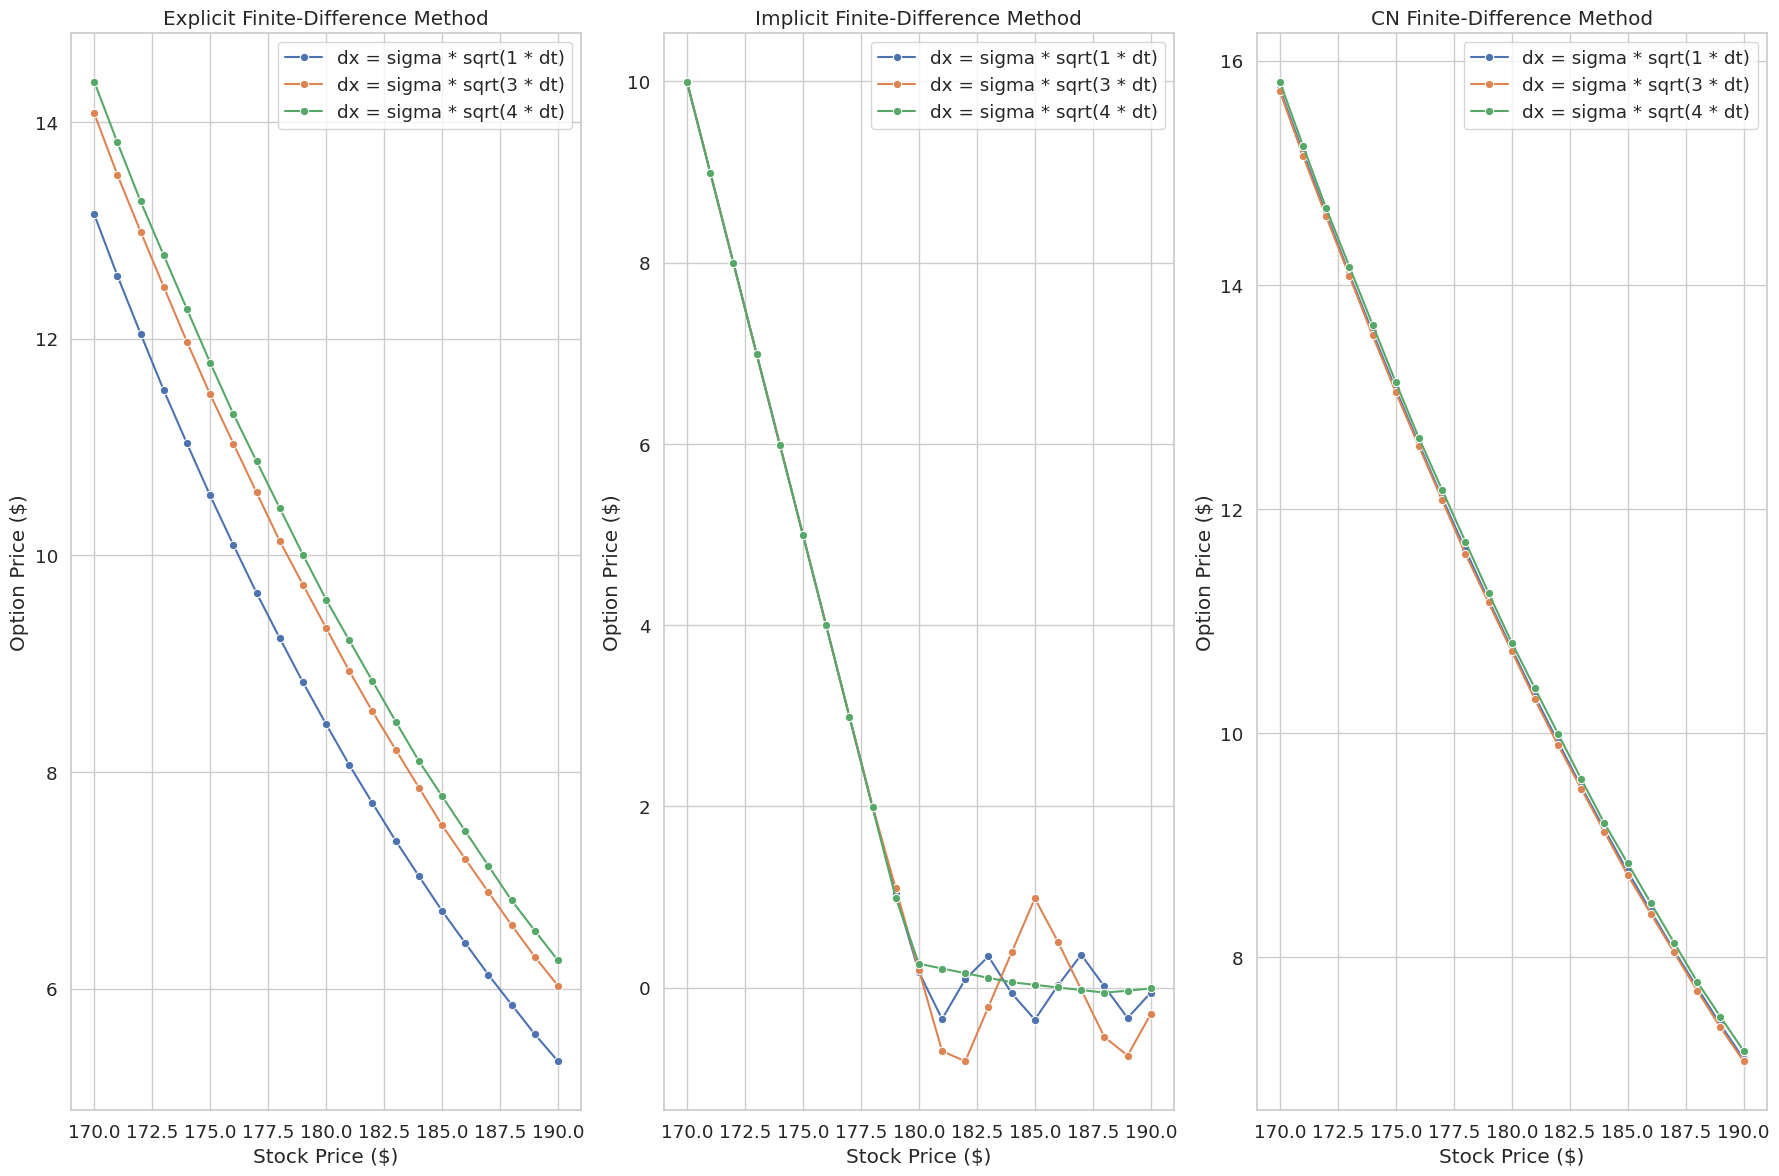

Option Prices:
             Explicit - dx = sigma * sqrt(1 * dt)  \
Stock Price                                         
170                                       13.1485   
171                                       12.5813   
172                                       12.0466   
173                                       11.5234   
174                                       11.0324   
175                                       10.5520   
176                                       10.0963   
177                                        9.6529   
178                                        9.2358   
179                                        8.8283   
180                                        8.4414   
181                                        8.0645   
182                                        7.7118   
183                                        7.3657   
184                                        7.0387   
185                                        6.7174   
186                            

In [7]:
def explicit_fd_log(K, sigma, T, r, dt, dx, S0_range):
    x_min = np.log(min(S0_range) * 0.5)
    x_max = np.log(max(S0_range) * 2.0)
    
    nx = int((x_max - x_min) / dx) + 1
    x = np.linspace(x_min, x_max, nx)
    
    nt = int(T / dt) + 1
    t = np.linspace(0, T, nt)
    
    v = np.zeros((nx, nt))
    for i in range(nx):
        S = np.exp(x[i])
        v[i, -1] = max(K - S, 0)
    
    alpha = dt / (dx**2)
    beta = dt / (2 * dx)
    gamma = r - sigma**2/2
    
    if alpha > 0.5:
        print(f"Warning: Explicit method may be unstable. alpha = {alpha} > 0.5")
    
    for j in range(nt-2, -1, -1):
        for i in range(1, nx-1):
            a = 0.5 * sigma**2 * alpha
            b = gamma * beta
            v[i, j] = a * v[i+1, j+1] + (1 - 2*a - r*dt) * v[i, j+1] + (a - b) * v[i-1, j+1]
            
            S = np.exp(x[i])
            v[i, j] = max(v[i, j], K - S)
        
        v[0, j] = K * np.exp(-r * (T - t[j]))
        v[nx-1, j] = 0
    
    prices = np.zeros(len(S0_range))
    for i, S0 in enumerate(S0_range):
        x0 = np.log(S0)
        idx = np.abs(x - x0).argmin()
        if x[idx] == x0:
            prices[i] = v[idx, 0]
        else:
            if x[idx] < x0 and idx < nx - 1:
                t = (x0 - x[idx]) / (x[idx+1] - x[idx])
                prices[i] = v[idx, 0] * (1 - t) + v[idx+1, 0] * t
            elif x[idx] > x0 and idx > 0:
                t = (x0 - x[idx-1]) / (x[idx] - x[idx-1])
                prices[i] = v[idx-1, 0] * (1 - t) + v[idx, 0] * t
            else:
                prices[i] = v[idx, 0]
    
    return prices

def implicit_fd_log(K, sigma, T, r, dt, dx, S0_range):
    x_min = np.log(min(S0_range) * 0.5)
    x_max = np.log(max(S0_range) * 2.0)
    
    nx = int((x_max - x_min) / dx) + 1
    x = np.linspace(x_min, x_max, nx)
    
    nt = int(T / dt) + 1
    t = np.linspace(0, T, nt)
    
    v = np.zeros((nx, nt))
    for i in range(nx):
        S = np.exp(x[i])
        v[i, -1] = max(K - S, 0)
    
    alpha = dt / (dx**2)
    beta = dt / (2 * dx)
    gamma = r - sigma**2/2
    
    for j in range(nt-2, -1, -1):
        a = 0.5 * sigma**2 * alpha
        b = gamma * beta
        
        lower_diag = np.ones(nx-2) * (a - b)
        main_diag = np.ones(nx-1) * (1 + 2*a + r*dt)
        upper_diag = np.ones(nx-2) * (a + b)
        
        A = diags([lower_diag, main_diag, upper_diag], [-1, 0, 1], shape=(nx-1, nx-1)).toarray()
        
        rhs = v[1:nx, j+1].copy()
        
        boundary_val = K * np.exp(-r * (T - t[j]))
        rhs[0] -= (a - b) * boundary_val
        
        v_new = np.linalg.solve(A, rhs)
        
        v[1:nx, j] = v_new
        v[0, j] = boundary_val
        
        for i in range(nx):
            S = np.exp(x[i])
            v[i, j] = max(v[i, j], K - S)
    
    prices = np.zeros(len(S0_range))
    for i, S0 in enumerate(S0_range):
        x0 = np.log(S0)
        idx = np.abs(x - x0).argmin()
        if x[idx] == x0:
            prices[i] = v[idx, 0]
        else:
            if x[idx] < x0 and idx < nx - 1:
                t = (x0 - x[idx]) / (x[idx+1] - x[idx])
                prices[i] = v[idx, 0] * (1 - t) + v[idx+1, 0] * t
            elif x[idx] > x0 and idx > 0:
                t = (x0 - x[idx-1]) / (x[idx] - x[idx-1])
                prices[i] = v[idx-1, 0] * (1 - t) + v[idx, 0] * t
            else:
                prices[i] = v[idx, 0]
    
    return prices

def crank_nicolson_fd_log(K, sigma, T, r, dt, dx, S0_range):
    x_min = np.log(min(S0_range) * 0.5)
    x_max = np.log(max(S0_range) * 2.0)
    
    nx = int((x_max - x_min) / dx) + 1
    x = np.linspace(x_min, x_max, nx)
    
    nt = int(T / dt) + 1
    t = np.linspace(0, T, nt)
    
    v = np.zeros((nx, nt))
    for i in range(nx):
        S = np.exp(x[i])
        v[i, -1] = max(K - S, 0)
    
    alpha = dt / (2 * dx**2)
    beta = dt / (4 * dx)
    gamma = r - sigma**2/2
    
    for j in range(nt-2, -1, -1):
        a = 0.5 * sigma**2 * alpha
        b = gamma * beta
        
        lower_diag_A = np.ones(nx-2) * (-a + b)
        main_diag_A = np.ones(nx-1) * (1 + 2*a + 0.5*r*dt)
        upper_diag_A = np.ones(nx-2) * (-a - b)
        
        A = diags([lower_diag_A, main_diag_A, upper_diag_A], [-1, 0, 1], shape=(nx-1, nx-1)).toarray()
        
        lower_diag_B = np.ones(nx-2) * (a - b)
        main_diag_B = np.ones(nx-1) * (1 - 2*a - 0.5*r*dt)
        upper_diag_B = np.ones(nx-2) * (a + b)
        
        B = diags([lower_diag_B, main_diag_B, upper_diag_B], [-1, 0, 1], shape=(nx-1, nx-1)).toarray()
        
        rhs = B @ v[1:nx, j+1]
        
        boundary_val = K * np.exp(-r * (T - t[j]))
        rhs[0] += (-a + b) * boundary_val
        
        v_new = np.linalg.solve(A, rhs)
        
        v[1:nx, j] = v_new
        v[0, j] = boundary_val
        v[nx-1, j] = 0
        
        for i in range(nx):
            S = np.exp(x[i])
            v[i, j] = max(v[i, j], K - S)
    
    prices = np.zeros(len(S0_range))
    for i, S0 in enumerate(S0_range):
        x0 = np.log(S0)
        idx = np.abs(x - x0).argmin()
        if x[idx] == x0:
            prices[i] = v[idx, 0]
        else:
            if x[idx] < x0 and idx < nx - 1:
                t = (x0 - x[idx]) / (x[idx+1] - x[idx])
                prices[i] = v[idx, 0] * (1 - t) + v[idx+1, 0] * t
            elif x[idx] > x0 and idx > 0:
                t = (x0 - x[idx-1]) / (x[idx] - x[idx-1])
                prices[i] = v[idx-1, 0] * (1 - t) + v[idx, 0] * t
            else:
                prices[i] = v[idx, 0]
    
    return prices

K = 180
sigma = 0.25
T = 0.5
r = 0.055
dt = 0.002

S0_range = np.arange(170, 191, 1)

multiples = [1, 3, 4]
dx_values = [sigma * np.sqrt(multiple * dt) for multiple in multiples]

prices = {}
for i, dx in enumerate(dx_values):
    multiple = multiples[i]
    label = f"dx = sigma * sqrt({multiple} * dt)"
    
    prices.setdefault('Explicit', {})[label] = explicit_fd_log(K, sigma, T, r, dt, dx, S0_range)
    
    prices.setdefault('Implicit', {})[label] = implicit_fd_log(K, sigma, T, r, dt, dx, S0_range)
    
    prices.setdefault('CN', {})[label] = crank_nicolson_fd_log(K, sigma, T, r, dt, dx, S0_range)

plt.figure(figsize=(18, 12))

for i, method in enumerate(['Explicit', 'Implicit', 'CN']):
    plt.subplot(1, 3, i+1)
    for label, price_array in prices[method].items():
        sns.lineplot(x=S0_range, y=price_array, marker='o', label=label)
    
    plt.title(f'{method} Finite-Difference Method')
    plt.xlabel('Stock Price ($)')
    plt.ylabel('Option Price ($)')
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

results_table = {}
for S0 in S0_range:
    results_table[S0] = {}
    for method in ['Explicit', 'Implicit', 'CN']:
        for label in prices[method].keys():
            idx = np.where(S0_range == S0)[0][0]
            results_table[S0][f"{method} - {label}"] = prices[method][label][idx]

results_df = pd.DataFrame(results_table).T
results_df.index.name = 'Stock Price'

reference_prices = prices['CN'][f"dx = sigma * sqrt({multiples[0]} * dt)"]

error_df = pd.DataFrame(index=S0_range)
for method in ['Explicit', 'Implicit', 'CN']:
    for label in prices[method].keys():
        current_prices = prices[method][label]
        rel_error = 100 * np.abs(current_prices - reference_prices) / reference_prices
        error_df[f"{method} - {label} (% Error)"] = rel_error

print("Option Prices:")
print(results_df.round(4))
print("\nRelative Errors (%)")
print(error_df.round(2))

6. Consider the following information on the stock of company XYZ: The volatility of the stock price is $\sigma = 25\%$ per annum. Assume the prevailing risk-free rate is $r = 5.5\%$ per annum.

Use the Black-Scholes PDE (for S) to price American Put options with strike prices of $K = 180$, expiration of 6 months and current stock prices for a range from $170 to $190; using the specified methods below:

**(a)** Explicit Finite-Difference method,  
**(b)** Implicit Finite-Difference method,  
**(c)** Crank-Nicolson Finite-Difference method.

Choose $\Delta t = 0.002$, with $\Delta S = 0.5$, or with $\Delta S = 1$.

Inputs: $K, \sigma, T, \Delta t$

Outputs:

i. Values: $C_a, C_b, C_c, P_a, P_b, P_c$ for the American put options using each of the methods (a), (b), and (c).

ii. Graphs: Plot the American Put option price as a function of the current stock price from $170 to $190 in $1 increments for methods (a), (b), and (c) on the same graph. Use a color legend or linestyles to differentiate the plots. Place the two graphs in a .pdf file.

## Problem 6: Numerical PDE Methods on Original Black-Scholes PDE

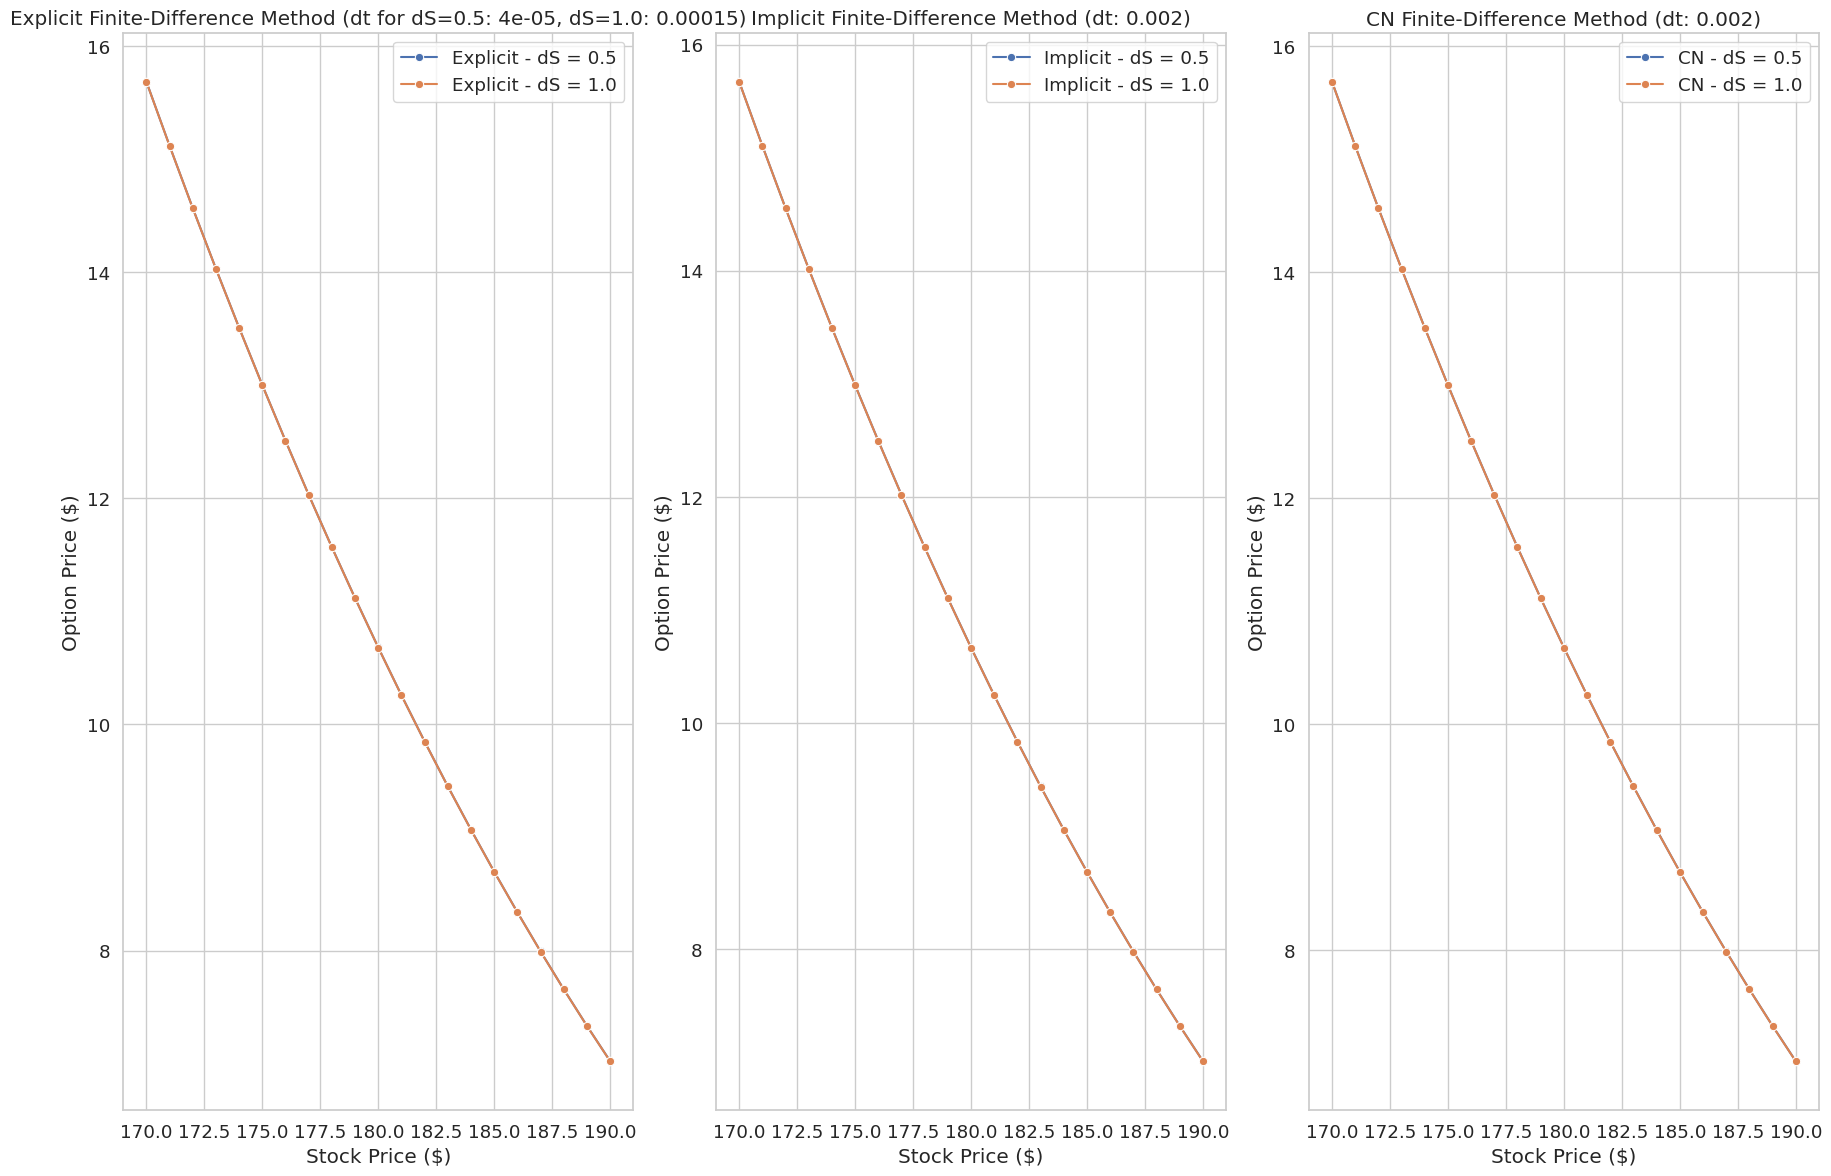

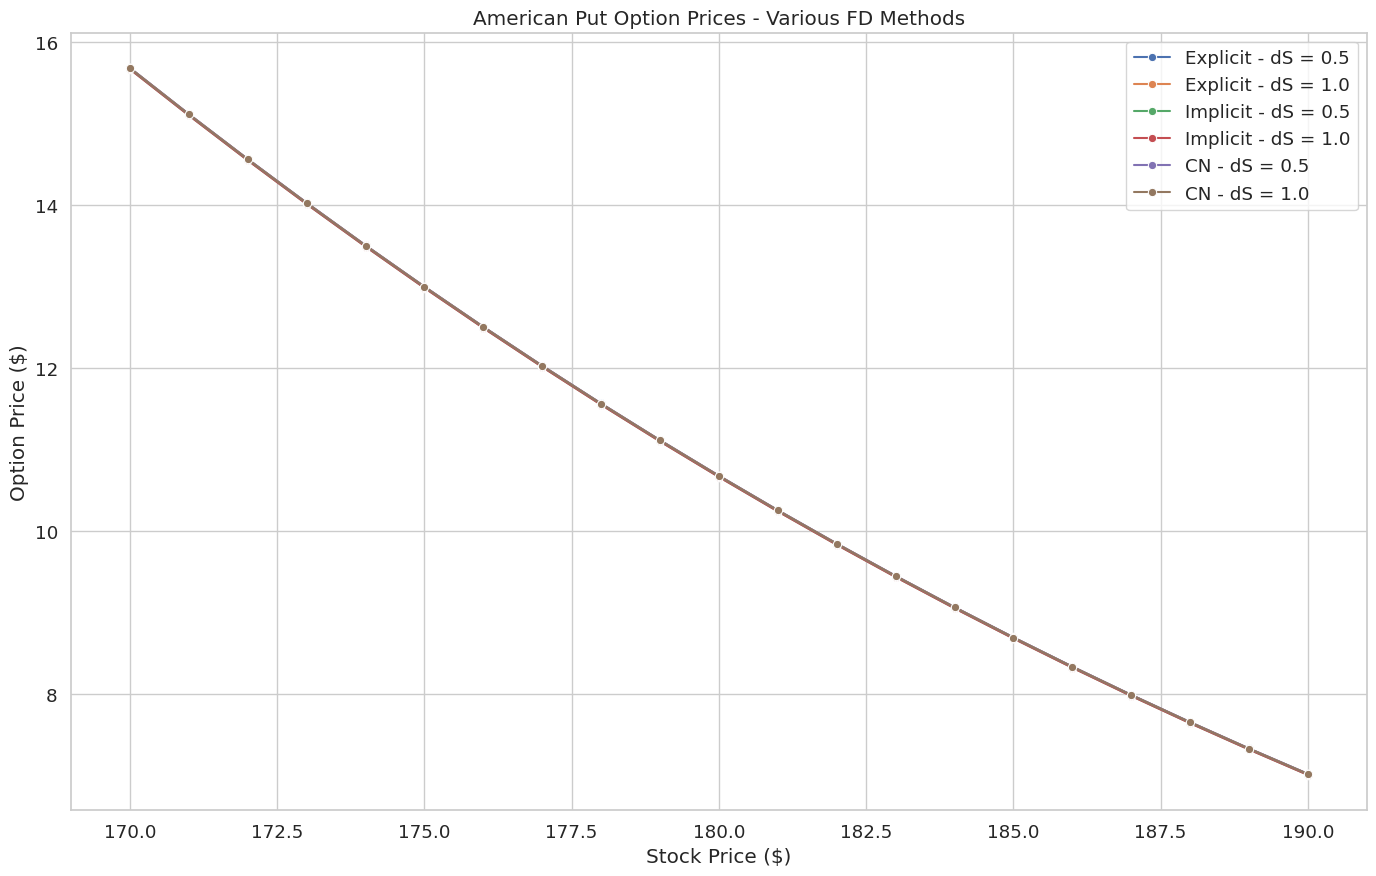

In [ ]:


def explicit_fd_bs(K, sigma, T, r, dt, dS, S0_range):
    S_min = max(min(S0_range) - 50, 1.0)
    S_max = max(S0_range) + 100.0
    
    nS = int(round((S_max - S_min) / dS)) + 1
    S = np.linspace(S_min, S_max, nS)
    
    nt = int(round(T / dt)) + 1
    time_grid = np.linspace(0, T, nt) 
    
    v = np.zeros((nS, nt))
    
    payoff = np.maximum(K - S, 0)
    v[:, -1] = payoff
    
    for j in range(nt - 2, -1, -1):
        v[0, j] = K - S[0] 
        v[nS - 1, j] = 0.0
        
        for i in range(1, nS - 1):
            Si = S[i]
            
            coeff_Si2_term = sigma**2 * Si**2 * dt / dS**2
            coeff_Si_term = r * Si * dt / dS
            
            v[i, j] = (0.5 * coeff_Si2_term - 0.5 * coeff_Si_term) * v[i-1, j+1] + \
                        (1.0 - coeff_Si2_term - r * dt) * v[i, j+1] + \
                        (0.5 * coeff_Si2_term + 0.5 * coeff_Si_term) * v[i+1, j+1]
        
        v[:, j] = np.maximum(v[:, j], payoff)

    prices = np.zeros(len(S0_range))
    for i_S0, S0_val in enumerate(S0_range):
        idx = np.abs(S - S0_val).argmin()
        if np.isclose(S[idx], S0_val):
            prices[i_S0] = v[idx, 0]
        else:
            if S[idx] < S0_val and idx + 1 < nS:
                interp_ratio = (S0_val - S[idx]) / (S[idx+1] - S[idx])
                prices[i_S0] = v[idx, 0] * (1 - interp_ratio) + v[idx+1, 0] * interp_ratio
            elif S[idx] > S0_val and idx > 0:
                interp_ratio = (S0_val - S[idx-1]) / (S[idx] - S[idx-1])
                prices[i_S0] = v[idx-1, 0] * (1 - interp_ratio) + v[idx, 0] * interp_ratio
            else:
                prices[i_S0] = v[idx, 0]
    
    return prices

def implicit_fd_bs(K, sigma, T, r, dt, dS, S0_range):
    S_min = max(min(S0_range) - 50, 1.0)
    S_max = max(S0_range) + 100.0
    
    nS = int(round((S_max - S_min) / dS)) + 1
    S = np.linspace(S_min, S_max, nS)
    
    nt = int(round(T / dt)) + 1
    time_grid = np.linspace(0, T, nt)
    
    v = np.zeros((nS, nt))
    
    payoff = np.maximum(K - S, 0)
    v[:, -1] = payoff
    
    alpha = 0.5 * sigma**2 * S**2 * dt / dS**2
    beta = 0.5 * r * S * dt / dS
    
    
    lower_diag_coeffs = beta[1:nS-1] - alpha[1:nS-1]
    main_diag_coeffs = 1.0 + 2 * alpha[1:nS-1] + r * dt
    upper_diag_coeffs = -beta[1:nS-1] - alpha[1:nS-1]
    
    if nS <= 2:
        if nS == 1:
             v[0, :] = np.maximum(K - S[0],0)
        elif nS == 2:
             v[0, :] = np.maximum(K - S[0],0)
             v[1, :] = np.maximum(K - S[1],0)

        prices = np.zeros(len(S0_range))
        for i_S0, S0_val in enumerate(S0_range):
            idx = np.abs(S - S0_val).argmin()
            prices[i_S0] = v[idx, 0]
        return prices

    A_matrix = diags([lower_diag_coeffs[1:], main_diag_coeffs, upper_diag_coeffs[:-1]], [-1, 0, 1], shape=(nS-2, nS-2)).toarray()
    
    for j in range(nt - 2, -1, -1):
        rhs_b_vector = v[1:nS-1, j+1].copy()
        
        boundary_val_S_min_j = K - S[0]
        boundary_val_S_max_j = 0.0

        rhs_b_vector[0] -= lower_diag_coeffs[0] * boundary_val_S_min_j
        rhs_b_vector[-1] -= upper_diag_coeffs[-1] * boundary_val_S_max_j
        
        v_interior = np.linalg.solve(A_matrix, rhs_b_vector)
        
        v[1:nS-1, j] = v_interior
        v[0, j] = boundary_val_S_min_j
        v[nS-1, j] = boundary_val_S_max_j
        
        v[:, j] = np.maximum(v[:, j], payoff)
    
    prices = np.zeros(len(S0_range))
    for i_S0, S0_val in enumerate(S0_range):
        idx = np.abs(S - S0_val).argmin()
        if np.isclose(S[idx], S0_val):
            prices[i_S0] = v[idx, 0]
        else:
            if S[idx] < S0_val and idx + 1 < nS:
                interp_ratio = (S0_val - S[idx]) / (S[idx+1] - S[idx])
                prices[i_S0] = v[idx, 0] * (1 - interp_ratio) + v[idx+1, 0] * interp_ratio
            elif S[idx] > S0_val and idx > 0:
                interp_ratio = (S0_val - S[idx-1]) / (S[idx] - S[idx-1])
                prices[i_S0] = v[idx-1, 0] * (1 - interp_ratio) + v[idx, 0] * interp_ratio
            else:
                prices[i_S0] = v[idx, 0]
                
    return prices

def crank_nicolson_fd_bs(K, sigma, T, r, dt, dS, S0_range):
    S_min = max(min(S0_range) - 50, 1.0)
    S_max = max(S0_range) + 100.0
    
    nS = int(round((S_max - S_min) / dS)) + 1
    S = np.linspace(S_min, S_max, nS)
    
    nt = int(round(T / dt)) + 1
    time_grid = np.linspace(0, T, nt)
        
    v = np.zeros((nS, nt))
    
    payoff = np.maximum(K - S, 0)
    v[:, -1] = payoff
    
    alpha_cn_half = 0.25 * sigma**2 * S**2 * dt / dS**2 
    beta_cn_half = 0.25 * r * S * dt / dS           

    if nS <= 2:
        if nS == 1:
             v[0, :] = np.maximum(K - S[0],0)
        elif nS == 2:
             v[0, :] = np.maximum(K - S[0],0)
             v[1, :] = np.maximum(K - S[1],0)

        prices = np.zeros(len(S0_range))
        for i_S0, S0_val in enumerate(S0_range):
            idx = np.abs(S - S0_val).argmin()
            prices[i_S0] = v[idx, 0]
        return prices

    m1_lower_coeffs = beta_cn_half[1:nS-1] - alpha_cn_half[1:nS-1]
    m1_main_coeffs = 1.0 + 2.0 * alpha_cn_half[1:nS-1] + 0.5 * r * dt
    m1_upper_coeffs = -beta_cn_half[1:nS-1] - alpha_cn_half[1:nS-1]
    M1_matrix = diags([m1_lower_coeffs[1:], m1_main_coeffs, m1_upper_coeffs[:-1]], [-1, 0, 1], shape=(nS-2, nS-2)).toarray()
    
    m2_lower_coeffs = -(beta_cn_half[1:nS-1] - alpha_cn_half[1:nS-1])
    m2_main_coeffs = 1.0 - 2.0 * alpha_cn_half[1:nS-1] - 0.5 * r * dt
    m2_upper_coeffs = -(-beta_cn_half[1:nS-1] - alpha_cn_half[1:nS-1])
    M2_matrix = diags([m2_lower_coeffs[1:], m2_main_coeffs, m2_upper_coeffs[:-1]], [-1, 0, 1], shape=(nS-2, nS-2)).toarray()
        
    for j in range(nt - 2, -1, -1):
        rhs_cn_vector = M2_matrix @ v[1:nS-1, j+1]
        
        boundary_val_S_min_j = K - S[0]
        boundary_val_S_max_j = 0.0
        
        val_S_min_jplus1 = v[0, j+1] 
        val_S_max_jplus1 = v[nS-1, j+1]

        rhs_cn_vector[0] -= m1_lower_coeffs[0] * boundary_val_S_min_j
        rhs_cn_vector[0] -= m2_lower_coeffs[0] * val_S_min_jplus1 
        
        rhs_cn_vector[-1] -= m1_upper_coeffs[-1] * boundary_val_S_max_j
        rhs_cn_vector[-1] -= m2_upper_coeffs[-1] * val_S_max_jplus1
                
        v_interior = np.linalg.solve(M1_matrix, rhs_cn_vector)
        
        v[1:nS-1, j] = v_interior
        v[0, j] = boundary_val_S_min_j
        v[nS-1, j] = boundary_val_S_max_j
        
        v[:, j] = np.maximum(v[:, j], payoff)
        
    prices = np.zeros(len(S0_range))
    for i_S0, S0_val in enumerate(S0_range):
        idx = np.abs(S - S0_val).argmin()
        if np.isclose(S[idx], S0_val):
            prices[i_S0] = v[idx, 0]
        else:
            if S[idx] < S0_val and idx + 1 < nS:
                interp_ratio = (S0_val - S[idx]) / (S[idx+1] - S[idx])
                prices[i_S0] = v[idx, 0] * (1 - interp_ratio) + v[idx+1, 0] * interp_ratio
            elif S[idx] > S0_val and idx > 0:
                interp_ratio = (S0_val - S[idx-1]) / (S[idx] - S[idx-1])
                prices[i_S0] = v[idx-1, 0] * (1 - interp_ratio) + v[idx, 0] * interp_ratio
            else:
                prices[i_S0] = v[idx, 0]
                
    return prices

K = 180
sigma = 0.25
T = 0.5
r = 0.055
dt_explicit = 0.00004
dt_implicit_cn = 0.002


dS_values = [0.5, 1.0]

S0_range = np.arange(170, 191, 1)

prices_bs = {}
for dS_val in dS_values:
    label = f"dS = {dS_val}"
    
    current_dt_explicit = dt_explicit 
    if dS_val == 1.0:
        
        current_dt_explicit = 0.00015

    prices_bs.setdefault('Explicit', {})[label] = explicit_fd_bs(K, sigma, T, r, current_dt_explicit, dS_val, S0_range)
    
    prices_bs.setdefault('Implicit', {})[label] = implicit_fd_bs(K, sigma, T, r, dt_implicit_cn, dS_val, S0_range)
    
    prices_bs.setdefault('CN', {})[label] = crank_nicolson_fd_bs(K, sigma, T, r, dt_implicit_cn, dS_val, S0_range)

plt.figure(figsize=(18, 12))

for i, method in enumerate(['Explicit', 'Implicit', 'CN']):
    plt.subplot(1, 3, i+1)
    dt_used_info = ""
    if method == 'Explicit':
        
        dt_used_info = f" (dt for dS=0.5: {dt_explicit}, dS=1.0: {0.00015})" 
    else:
        dt_used_info = f" (dt: {dt_implicit_cn})"

    for label, price_array in prices_bs[method].items():
        sns.lineplot(x=S0_range, y=price_array, marker='o', label=f"{method} - {label}")
    
    plt.title(f'{method} Finite-Difference Method{dt_used_info}')
    plt.xlabel('Stock Price ($)')
    plt.ylabel('Option Price ($)')
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 9))

for method in ['Explicit', 'Implicit', 'CN']:
    for label, price_array in prices_bs[method].items():
        sns.lineplot(x=S0_range, y=price_array, marker='o', label=f"{method} - {label}")

plt.title('American Put Option Prices - Various FD Methods')
plt.xlabel('Stock Price ($)')
plt.ylabel('Option Price ($)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()